# 03. Baseline Model (Pre-Event)

**Input:** `disaster_train.xlsx` / `disaster_test.xlsx` (from EDA)

**Goal:** Predict disaster type using only pre-event features.

**Pipeline:**

1. Load train / test
2. Fit preprocessing on **Train only**
3. Transform Test
4. Train baseline models
5. Evaluate (Macro-F1)

**Primary metric:** Macro-F1


## 1. Libraries


In [28]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

## 2. Load train / test

These files already have:

- Target created
- Post-event & leaky columns dropped
- Stratified 80/20 split


In [29]:
train_df = pd.read_excel("../data/processed/disaster_train.xlsx")
test_df  = pd.read_excel("../data/processed/disaster_test.xlsx")

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print()
print("Columns:", train_df.columns.tolist())
print()
print("Train target distribution:")
print(train_df["target"].value_counts())


Train: (13979, 14)
Test : (3495, 14)

Columns: ['Country', 'Subregion', 'Region', 'Origin', 'Associated Types', 'Magnitude', 'Magnitude Scale', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'target']

Train target distribution:
target
Flood           4946
Storm           4042
Earthquake      1321
Epidemic        1298
Landslide        734
Drought          643
Extreme Temp     584
Wildfire         411
Name: count, dtype: int64


## 3. Preprocessing functions

- `fit_preprocess` → learn from **Train only**
- `transform_preprocess` → apply to Train or Test


In [30]:
def _compute_duration(row):
    """Approximate event duration in days."""
    try:
        sy = int(row["Start Year"])
        sm = int(row["Start Month"])
        sd = int(min(row["Start Day"], 28))
        ey = int(row["End Year"]) if pd.notna(row["End Year"]) else sy
        em = int(row["End Month"]) if pd.notna(row["End Month"]) else sm
        ed = int(min(row["End Day"], 28)) if pd.notna(row["End Day"]) else sd
        start = pd.Timestamp(year=sy, month=min(max(sm, 1), 12), day=max(sd, 1))
        end   = pd.Timestamp(year=ey, month=min(max(em, 1), 12), day=max(ed, 1))
        return max((end - start).days, 0)
    except Exception:
        return np.nan


def fit_preprocess(train):
    """Fit statistics on TRAIN only."""
    t = train.copy()

    # numeric time
    for col in ["Start Year", "Start Month", "Start Day", "End Year", "End Month", "End Day"]:
        if col in t.columns:
            t[col] = pd.to_numeric(t[col], errors="coerce")

    month_median = t["Start Month"].median()
    day_median   = t["Start Day"].median()
    year_median  = t["Start Year"].median()

    t["Start Month"] = t["Start Month"].fillna(month_median)
    t["Start Day"]   = t["Start Day"].fillna(day_median)
    t["Start Year"]  = t["Start Year"].fillna(year_median)

    # cyclical
    t["start_month_sin"] = np.sin(2 * np.pi * t["Start Month"] / 12)
    t["start_month_cos"] = np.cos(2 * np.pi * t["Start Month"] / 12)
    t["start_day_sin"]   = np.sin(2 * np.pi * t["Start Day"] / 31)
    t["start_day_cos"]   = np.cos(2 * np.pi * t["Start Day"] / 31)

    # duration
    t["duration_days"] = t.apply(_compute_duration, axis=1)
    duration_median = t["duration_days"].median()
    t["duration_days"] = t["duration_days"].fillna(duration_median).clip(lower=0)
    t["event_duration_log"] = np.log1p(t["duration_days"])

    # magnitude
    t["magnitude_missing"] = t["Magnitude"].isna().astype(int)
    mag_median = t["Magnitude"].median()
    t["Magnitude"] = t["Magnitude"].fillna(mag_median).clip(lower=0)
    mag_mean = t["Magnitude"].mean()
    mag_std  = t["Magnitude"].std() + 1e-9
    t["magnitude_scaled"] = (t["Magnitude"] - mag_mean) / mag_std

    # magnitude scale one-hot
    t["Magnitude Scale"] = t["Magnitude Scale"].fillna("Unknown").astype(str).str.strip()
    scale_cats = sorted(t["Magnitude Scale"].unique().tolist())
    for cat in scale_cats:
        safe = cat.replace(" ", "_").replace("°", "")
        t[f"mag_scale_{safe}"] = (t["Magnitude Scale"] == cat).astype(int)

    # location
    for col in ["Region", "Subregion", "Country"]:
        if col in t.columns:
            t[col] = t[col].fillna("Unknown").astype(str).str.strip()

    region_cats    = sorted(t["Region"].unique().tolist()) if "Region" in t.columns else []
    subregion_cats = sorted(t["Subregion"].unique().tolist()) if "Subregion" in t.columns else []
    country_freq   = t["Country"].value_counts(normalize=True).to_dict() if "Country" in t.columns else {}
    t["country_freq"] = t["Country"].map(country_freq).fillna(0)

    for cat in region_cats:
        t[f"region_{cat}"] = (t["Region"] == cat).astype(int)
    for cat in subregion_cats:
        t[f"subregion_{cat}"] = (t["Subregion"] == cat).astype(int)

    # optional frequency features
    origin_freq, assoc_freq = {}, {}
    if "Origin" in t.columns:
        t["Origin"] = t["Origin"].fillna("Unknown").astype(str)
        origin_freq = t["Origin"].value_counts(normalize=True).to_dict()
        t["origin_freq"] = t["Origin"].map(origin_freq).fillna(0)

    if "Associated Types" in t.columns:
        t["Associated Types"] = t["Associated Types"].fillna("Unknown").astype(str)
        assoc_freq = t["Associated Types"].value_counts(normalize=True).to_dict()
        t["assoc_freq"] = t["Associated Types"].map(assoc_freq).fillna(0)

    params = {
        "month_median": month_median,
        "day_median": day_median,
        "year_median": year_median,
        "duration_median": duration_median,
        "mag_median": mag_median,
        "mag_mean": mag_mean,
        "mag_std": mag_std,
        "scale_cats": scale_cats,
        "region_cats": region_cats,
        "subregion_cats": subregion_cats,
        "country_freq": country_freq,
        "origin_freq": origin_freq,
        "assoc_freq": assoc_freq,
    }
    return t, params


def transform_preprocess(data, params):
    """Apply Train statistics to any dataframe."""
    t = data.copy()

    for col in ["Start Year", "Start Month", "Start Day", "End Year", "End Month", "End Day"]:
        if col in t.columns:
            t[col] = pd.to_numeric(t[col], errors="coerce")

    t["Start Month"] = t["Start Month"].fillna(params["month_median"])
    t["Start Day"]   = t["Start Day"].fillna(params["day_median"])
    t["Start Year"]  = t["Start Year"].fillna(params["year_median"])

    t["start_month_sin"] = np.sin(2 * np.pi * t["Start Month"] / 12)
    t["start_month_cos"] = np.cos(2 * np.pi * t["Start Month"] / 12)
    t["start_day_sin"]   = np.sin(2 * np.pi * t["Start Day"] / 31)
    t["start_day_cos"]   = np.cos(2 * np.pi * t["Start Day"] / 31)

    t["duration_days"] = t.apply(_compute_duration, axis=1)
    t["duration_days"] = t["duration_days"].fillna(params["duration_median"]).clip(lower=0)
    t["event_duration_log"] = np.log1p(t["duration_days"])

    t["magnitude_missing"] = t["Magnitude"].isna().astype(int)
    t["Magnitude"] = t["Magnitude"].fillna(params["mag_median"]).clip(lower=0)
    t["magnitude_scaled"] = (t["Magnitude"] - params["mag_mean"]) / params["mag_std"]

    t["Magnitude Scale"] = t["Magnitude Scale"].fillna("Unknown").astype(str).str.strip()
    for cat in params["scale_cats"]:
        safe = cat.replace(" ", "_").replace("°", "")
        t[f"mag_scale_{safe}"] = (t["Magnitude Scale"] == cat).astype(int)

    for col in ["Region", "Subregion", "Country"]:
        if col in t.columns:
            t[col] = t[col].fillna("Unknown").astype(str).str.strip()

    t["country_freq"] = t["Country"].map(params["country_freq"]).fillna(0) if "Country" in t.columns else 0

    for cat in params["region_cats"]:
        t[f"region_{cat}"] = (t["Region"] == cat).astype(int)
    for cat in params["subregion_cats"]:
        t[f"subregion_{cat}"] = (t["Subregion"] == cat).astype(int)

    if "Origin" in t.columns:
        t["Origin"] = t["Origin"].fillna("Unknown").astype(str)
        t["origin_freq"] = t["Origin"].map(params["origin_freq"]).fillna(0)

    if "Associated Types" in t.columns:
        t["Associated Types"] = t["Associated Types"].fillna("Unknown").astype(str)
        t["assoc_freq"] = t["Associated Types"].map(params["assoc_freq"]).fillna(0)

    return t


print("Preprocessing functions defined")


Preprocessing functions defined


## 4. Fit on Train → Transform Test


In [31]:
train_processed, params = fit_preprocess(train_df)
test_processed = transform_preprocess(test_df, params)

print("Train processed:", train_processed.shape)
print("Test processed :", test_processed.shape)


Train processed: (13979, 53)
Test processed : (3495, 53)


## 5. Build feature matrix (X) and target (y)

- Features from processed frames
- Target from original train_df / test_df


In [32]:
# feature list
feature_cols = [
    "Start Year",
    "start_month_sin", "start_month_cos",
    "start_day_sin", "start_day_cos",
    "event_duration_log",
    "magnitude_missing", "magnitude_scaled",
    "country_freq",
]
feature_cols += [c for c in train_processed.columns if c.startswith("mag_scale_")]
feature_cols += [c for c in train_processed.columns if c.startswith("region_")]
feature_cols += [c for c in train_processed.columns if c.startswith("subregion_")]

if "origin_freq" in train_processed.columns:
    feature_cols.append("origin_freq")
if "assoc_freq" in train_processed.columns:
    feature_cols.append("assoc_freq")

feature_cols = [c for c in feature_cols if c in train_processed.columns]
print(f"Total features: {len(feature_cols)}")

# target from original split
le = LabelEncoder()
y_train = le.fit_transform(train_df["target"])
y_test  = le.transform(test_df["target"])

# feature matrices
X_train = train_processed[feature_cols].copy()
X_test  = test_processed[feature_cols].copy()

for c in feature_cols:
    if c not in X_test.columns:
        X_test[c] = 0
X_test = X_test[feature_cols]

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print("Classes:", list(le.classes_))


Total features: 39
X_train: (13979, 39)
X_test : (3495, 39)
y_train: (13979,) | y_test: (3495,)
Classes: ['Drought', 'Earthquake', 'Epidemic', 'Extreme Temp', 'Flood', 'Landslide', 'Storm', 'Wildfire']


## 6. Define models & evaluation function


In [33]:
class_names = list(le.classes_)


def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average="macro")
    weighted_f1 = f1_score(y_te, y_pred, average="weighted")

    print("=" * 65)
    print(name)
    print("=" * 65)
    print(f"Accuracy    : {acc:.4f}")
    print(f"Macro-F1    : {macro_f1:.4f}")
    print(f"Weighted-F1 : {weighted_f1:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=class_names, digits=3))

    return {
        "Model": name,
        "Accuracy": acc,
        "Macro-F1": macro_f1,
        "Weighted-F1": weighted_f1,
        "y_pred": y_pred,
        "model": model,
    }


models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Logistic Regression": LogisticRegression( max_iter=1000, random_state=42 ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, verbosity=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, eval_metric="mlogloss"
    ),
}

print("Models:", list(models.keys()))


Models: ['Decision Tree', 'SVM', 'Logistic Regression', 'Random Forest', 'LightGBM', 'XGBoost']


## 7. Train & evaluate


In [34]:
results = []
for name, model in models.items():
    res = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    results.append(res)


Decision Tree
Accuracy    : 0.8512
Macro-F1    : 0.5272
Weighted-F1 : 0.8029

              precision    recall  f1-score   support

     Drought      0.916     0.475     0.626       160
  Earthquake      1.000     1.000     1.000       330
    Epidemic      0.495     1.000     0.662       324
Extreme Temp      0.000     0.000     0.000       146
       Flood      0.871     0.998     0.930      1237
   Landslide      0.000     0.000     0.000       184
       Storm      1.000     1.000     1.000      1011
    Wildfire      0.000     0.000     0.000       103

    accuracy                          0.851      3495
   macro avg      0.535     0.559     0.527      3495
weighted avg      0.780     0.851     0.803      3495

SVM
Accuracy    : 0.3539
Macro-F1    : 0.0654
Weighted-F1 : 0.1850

              precision    recall  f1-score   support

     Drought      0.000     0.000     0.000       160
  Earthquake      0.000     0.000     0.000       330
    Epidemic      0.000     0.000     0.

## 8. Summary table


In [35]:
from sklearn.metrics import precision_score

summary = pd.DataFrame(
    [
        {
            "Model": r["Model"],
            "Accuracy": r["Accuracy"],
            "Precision Macro": precision_score(y_test, r["y_pred"], average="macro", zero_division=0),
            "Precision Weighted": precision_score(y_test, r["y_pred"], average="weighted", zero_division=0),
            "Macro-F1": r["Macro-F1"],
            "Weighted-F1": r["Weighted-F1"],
        }
        for r in results
    ]
).sort_values("Macro-F1", ascending=False).reset_index(drop=True)

print(summary.round(4).to_string(index=False))

              Model  Accuracy  Precision Macro  Precision Weighted  Macro-F1  Weighted-F1
           LightGBM    0.9599           0.9287              0.9583    0.9117       0.9585
            XGBoost    0.9597           0.9224              0.9580    0.9110       0.9585
      Random Forest    0.9559           0.9285              0.9540    0.8942       0.9526
Logistic Regression    0.9293           0.8915              0.9243    0.8197       0.9189
      Decision Tree    0.8512           0.5352              0.7799    0.5272       0.8029
                SVM    0.3539           0.0442              0.1253    0.0654       0.1850


## 9. Feature importance (best model)


Best model: LightGBM  (Macro-F1 = 0.9117)

Top 15 Feature Importances:
Start Year                  4535
country_freq                2992
event_duration_log          2095
origin_freq                 1554
start_day_cos               1364
start_month_sin             1317
start_month_cos             1289
start_day_sin               1267
magnitude_scaled             985
assoc_freq                   950
mag_scale_Km2                755
mag_scale_Unknown            586
region_Asia                  549
region_Africa                363
subregion_Eastern Europe     291


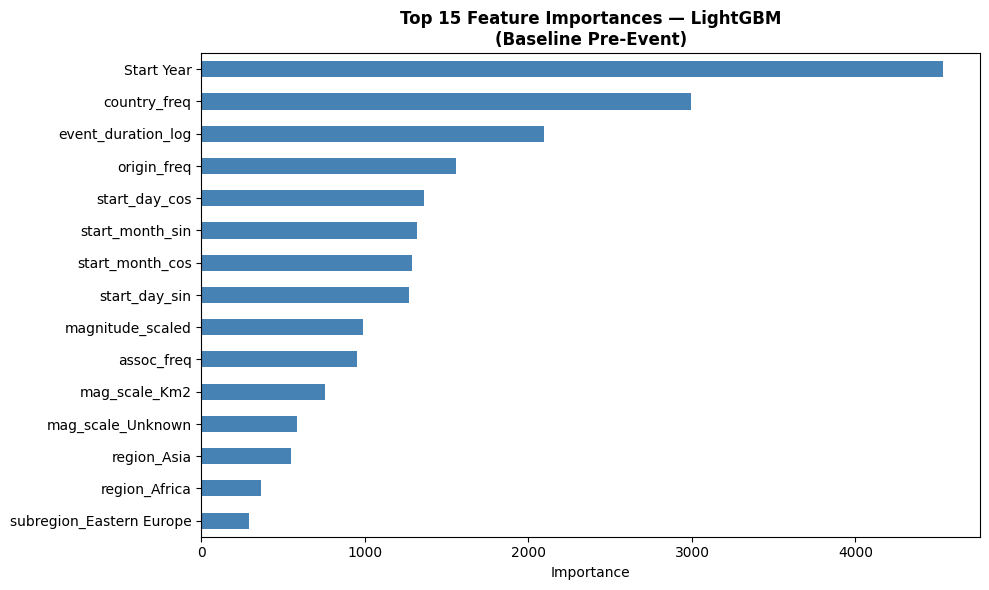

In [36]:
best = max(results, key=lambda x: x["Macro-F1"])
best_model = best["model"]
best_name  = best["Model"]

print(f"Best model: {best_name}  (Macro-F1 = {best['Macro-F1']:.4f})")

if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols)
    imp = imp.sort_values(ascending=False)

    print("\nTop 15 Feature Importances:")
    print(imp.head(15).round(4).to_string())

    plt.figure(figsize=(10, 6))
    imp.head(15).sort_values().plot(kind="barh", color="steelblue")
    plt.title(f"Top 15 Feature Importances — {best_name}\n(Baseline Pre-Event)", fontweight="bold")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} has no feature_importances_.")


## 10. Confusion matrix (best model)


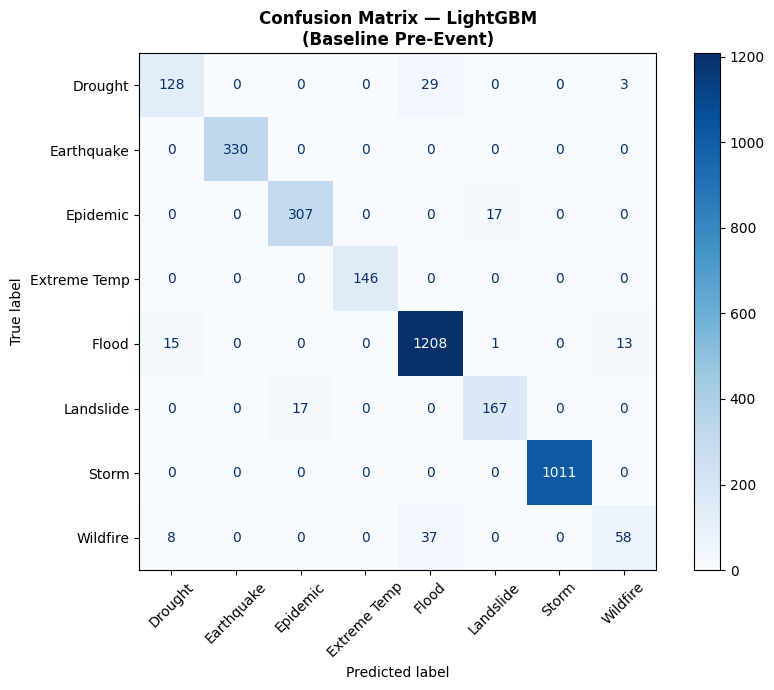

In [37]:
cm = confusion_matrix(y_test, best["y_pred"])

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
ax.set_title(
    f"Confusion Matrix — {best_name}\n(Baseline Pre-Event)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()


In [38]:
X_train.to_csv("../data/processed/X_train_processed.csv", index=False)
X_test.to_csv("../data/processed/X_test_processed.csv", index=False)

In [39]:
pd.DataFrame(y_train, columns=["target"]).to_csv(
    "../data/processed/y_train_processed.csv", index=False
)
pd.DataFrame(y_test, columns=["target"]).to_csv(
    "../data/processed/y_test_processed.csv", index=False
)


In [40]:
import joblib

joblib.dump(le, "../data/processed/label_encoder.pkl")


['../data/processed/label_encoder.pkl']